[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jose-milciades/NLP_taller_1/blob/main/notebook_taller_1.ipynb)

> **Nota sobre Google Colab:** diseñamos y validamos este cuaderno en Kaggle con **2 GPU Tesla T4** (`requested_gpus=2` en el PASO 02). La GPU gratuita de Colab suele ser una sola T4: si lo ejecutas allí, cambia `requested_gpus=1` en el PASO 02 antes de correrlo (o `allow_cpu_for_debug=True` para depurar sin GPU). Con una sola GPU el cuaderno corre igual, pero sin `DataParallel` y con tiempos de entrenamiento distintos a los reportados en el informe final.

# Sistema Híbrido de Reconocimiento de Entidades y Modelado Secuencial para Textos Clínicos en Español.

## Integrantes

**Carlos Javier Cepeda, David Salamanca, Jose Milciades Ordoñez**

## Objetivo:

Nuestro objetivo es construir un modelo de Procesamiento de Lenguaje Natural (NLP) que no solo procese palabras aisladas, sino que entienda el contexto y la terminología médica especializada para extraer información crítica (síntomas, medicamentos, patologías) de historias clínicas o diagnósticos.

## Definición del Modelo

El núcleo de nuestro proyecto es una arquitectura que fusiona conocimiento lingüístico simbólico (reglas y modelos estadísticos tradicionales) con aprendizaje profundo (Deep Learning).

En lugar de dejar que la red neuronal empiece a aprender desde cero qué es un verbo o un sustantivo, le entregamos el texto previamente analizado. Con esto resolvemos tareas de etiquetado de secuencias (Sequence Labeling), donde la red recibe una oración médica y debe predecir, token por token, a qué categoría clínica pertenece (por ejemplo, si la palabra "paracetamol" es un <FÁRMACO> o "cefalea" es un <SÍNTOMA>).

Para lograr esto como trabajo académico, basamos nuestro sistema en dos pilares:

- spaCy (El extractor de características): lo usamos como motor de preprocesamiento industrial. Con él analizamos la morfología, extraemos las raíces de las palabras (lemas) y detectamos la estructura gramatical básica (POS tagging).

- Red LSTM (El motor de contexto): la usamos como cerebro secuencial. Elegimos las redes con Memoria a Largo Plazo (LSTM) porque pueden "recordar" que un síntoma mencionado al inicio de un párrafo largo está directamente relacionado con un diagnóstico al final del mismo, mitigando el problema del desvanecimiento del gradiente.

Los escenarios de validación prueba se realizaron de la sigueiten manera:

-  Para evaluar el aporte de las características gramaticales POS, realizamos seis entrenamientos independientes. Comparamos dos variantes de la misma Bi-LSTM: una que utiliza embeddings de palabras junto con etiquetas POS obtenidas mediante spaCy, y otra que utiliza únicamente embeddings de palabras.

- Para medir la estabilidad de los resultados, entrenamos ambas variantes con tres semillas aleatorias: 42, 123 y 2026. En total, cada variante se entrenó tres veces. En todos los casos mantuvimos fija la partición de los datos, con 600 documentos para entrenamiento y 150 para validación. Además, se utilizaron 250 documentos independientes para el conjunto de pruebas. Estos documentos no participaron en el entrenamiento ni en la selección de la mejor época o variante; únicamente se utilizaron posteriormente para realizar la evaluación final del modelo seleccionado. De esta manera, las diferencias observadas durante la comparación no se deben a cambios en los documentos utilizados, sino principalmente a la inclusión de POS y a la variabilidad propia de la inicialización y el orden de los lotes. Al mantener el conjunto de pruebas separado, obtenemos una estimación más imparcial del comportamiento del modelo sobre documentos no utilizados durante su desarrollo.

- Antes de cada entrenamiento reiniciamos el modelo, el optimizador y los generadores aleatorios. También utilizamos los mismos hiperparámetros, número máximo de épocas y criterio de parada temprana. Para cada ejecución seleccionamos el checkpoint con mayor F1 en validación y posteriormente calculamos la media y la desviación estándar de las métricas.


## Justificación de la Arquitectura Propuesta

El desarrollo de modelos de Procesamiento de Lenguaje Natural (PLN) aplicados al dominio clínico exige un nivel de precisión y control que frecuentemente excede las capacidades de las soluciones comerciales de "caja negra" o arquitecturas preentrenadas genéricas. En este trabajo justificamos la implementación de una arquitectura híbrida —compuesta por un motor de extracción de características lingüísticas (spaCy) y una red neuronal secuencial personalizada (Bi-LSTM) en PyTorch— fundamentándonos en tres criterios metodológicos y técnicos centrales:

1. Inyección Simbólica y Enriquecimiento del Espacio Vectorial
Los modelos de aprendizaje profundo puro a menudo requieren volúmenes masivos de datos para inferir reglas gramaticales y sintácticas básicas. Al delegar la fase de preprocesamiento a una herramienta industrial como spaCy, no solo resolvemos la tokenización, sino que la usamos como inyector de conocimiento experto. Extraemos características morfológicas (Part-of-Speech tagging), lematización y dependencias sintácticas, y concatenamos esta información estática a los embeddings dinámicos de los tokens. Con esta fusión de PLN simbólico y representaciones distribuidas enriquecemos el vector de entrada, lo que permite a la red LSTM concentrar sus parámetros en aprender el contexto clínico subyacente en lugar de inferir la gramática del español desde cero.

2. Control Arquitectónico frente a la Asimetría de Clases
Los corpus clínicos, como el SPACCC (Spanish Clinical Case Corpus), presentan un desbalance de clases extremo intrínseco a su naturaleza: la vasta mayoría de los tokens pertenecen a la clase negativa (etiqueta "O" o Outside), mientras que las entidades de interés (patologías, fármacos, síntomas) constituyen una minoría dispersa. Como usar motores NER empaquetados oculta el cálculo del gradiente y la optimización de los pesos, limitando nuestra capacidad de intervención, implementamos la red LSTM desde los fundamentos matemáticos en PyTorch. Así habilitamos el diseño e integración de funciones de pérdida penalizadas (como Weighted Cross-Entropy o Focal Loss), y obtenemos control absoluto sobre cómo la red prioriza y aprende las representaciones de las entidades médicas minoritarias.

3. Transparencia Algorítmica y Rigor Investigativo
Desde una perspectiva de arquitectura de software y experimentación científica, depender exclusivamente de las capas ocultas de una librería de alto nivel restringe la capacidad de análisis. Por eso diseñamos explícitamente el forward pass temporal de la red Bidireccional Long Short-Term Memory (Bi-LSTM), lo que nos permite monitorear de forma granular los estados ocultos y evaluar el modelo de manera exhaustiva.

### PASO 01 — Dependencias y modelo lingüístico

Instalamos las bibliotecas que necesita nuestro cuaderno y el modelo español pequeño de spaCy. La ejecutamos una sola vez por sesión de Kaggle y requerimos Internet habilitado. Esta PASO no carga datos ni entrena redes. Si termina con `PASO 01 OK`, continuamos con el PASO 02; si Kaggle indica que hay que reiniciar el kernel, reinícialo y vuelve a ejecutar desde el PASO 02.

In [1]:
# PASO 01 — Dependencias (Internet activado; ejecutar una vez por sesión)
import sys, subprocess, importlib.util

packages = ['spacy>=3.8,<3.9', 'pandas>=2,<3', 'pyarrow>=14', 'requests>=2.31', 'tqdm>=4.66']
if importlib.util.find_spec('torch') is None:
    packages.append('torch>=2.2,<3')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
model_url = ('https://github.com/explosion/spacy-models/releases/download/'
             'es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', model_url])
print('PASO 01 OK. Dependencias instaladas. Continúa con la 02.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 72.6 MB/s eta 0:00:00
PASO 01 OK. Dependencias instaladas. Continúa con la 02.


### PASO 02 — Configuración, GPU y reproducibilidad

Definimos todos los hiperparámetros, las etiquetas BIO, los identificadores POS, las semillas y las rutas de salida. Comprobamos que Kaggle detecte exactamente las dos Tesla T4 y creamos el envoltorio `DataParallel` para repartir cada lote entre GPU 0 y GPU 1. También configuramos CUDA, semillas y memoria para que los tiempos y resultados puedan repetirse. Esta PASO no entrena: si falla con «se requieren 2 GPU», revisa el acelerador de Kaggle, activa GPU T4 ×2 y reinicia la sesión.

In [2]:
# PASO 02 — Partición fija y tres semillas: seis entrenamientos de hasta 20 épocas
import os, json, time, random, math, hashlib, platform, traceback
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import requests, spacy, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from tqdm.auto import tqdm

CFG = dict(split_seed=42, training_seeds=[42, 123, 2026], fraction=1.0, validation_fraction=0.20,
           epochs=20, patience=5, batch_size=16, max_tokens=128,
           embedding_dim=64, pos_dim=16, hidden_dim=64, layers=1,
           dropout=0.25, learning_rate=0.001, cpu_threads=min(4, os.cpu_count() or 1),
           spacy_model='es_core_news_sm', class_weights=True,
           run_final_test=False, final_test_variant=None, final_test_seed=None, requested_gpus=2, allow_cpu_for_debug=False)
assert 0 < CFG['fraction'] <= 1
assert 0 < CFG['validation_fraction'] < 1, 'Usa validation_fraction=0.20 para reservar el 20 %.'
assert isinstance(CFG['split_seed'], int) and 0 <= CFG['split_seed'] < 2**32
assert (isinstance(CFG['training_seeds'], list) and len(CFG['training_seeds']) >= 2
        and all(type(s) is int and 0 <= s < 2**32 for s in CFG['training_seeds'])
        and len(set(CFG['training_seeds'])) == len(CFG['training_seeds'])), 'Usa al menos dos semillas enteras distintas.'
random.seed(CFG['split_seed']); np.random.seed(CFG['split_seed']); torch.manual_seed(CFG['split_seed'])
torch.set_num_threads(CFG['cpu_threads'])
assert CFG['requested_gpus'] in (1, 2), 'requested_gpus debe ser 1 o 2.'
available_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
if available_gpus == 0 and CFG['allow_cpu_for_debug']:
    device_ids = []
    device = torch.device('cpu')
    print('AVISO: modo de depuración CPU explícito; NO valida CUDA ni las dos T4.')
elif available_gpus < CFG['requested_gpus']:
    raise RuntimeError(f'PASO 02: se requieren {CFG["requested_gpus"]} GPU CUDA y se detectaron '
                       f'{available_gpus}. En Kaggle selecciona GPU T4 x2 y reinicia la sesión. '
                       'Para usar deliberadamente una sola GPU cambia requested_gpus=1.')
else:
    device_ids = list(range(CFG['requested_gpus']))
    device = torch.device(f'cuda:{device_ids[0]}')
    torch.cuda.set_device(device)
    torch.cuda.manual_seed_all(CFG['split_seed'])
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False

def synchronize_devices():
    """Bloquea la ejecución hasta que todas las GPU usadas terminen sus operaciones
    pendientes (barrera de sincronización). La usamos antes/después de medir tiempos,
    porque las llamadas a CUDA son asíncronas y, sin sincronizar, los tiempos medidos
    en CPU no reflejarían el trabajo real de la GPU."""
    for index in device_ids:
        torch.cuda.synchronize(index)

def move_batch(batch):
    """Mueve todos los tensores de un lote (dict de tensores) al dispositivo de cómputo
    (GPU o CPU) definido en `device`."""
    # lengths también se reparte con DataParallel; cada réplica lo devuelve a CPU
    # en pack_padded_sequence, que exige longitudes en CPU.
    return {key: tensor.to(device, non_blocking=(device.type == 'cuda'))
            for key, tensor in batch.items()}

def unwrap(model):
    """Devuelve el modelo real dentro de un envoltorio `nn.DataParallel`, o el modelo
    tal cual si no está envuelto. La usamos para acceder a atributos del modelo
    (por ejemplo `pos_embedding`) o para guardar/cargar sus pesos sin el prefijo
    que agrega DataParallel."""
    return model.module if isinstance(model, nn.DataParallel) else model

def prepare_model(base):
    """Envía el modelo al dispositivo de cómputo y, si hay más de una GPU disponible,
    lo envuelve en `nn.DataParallel` para repartir cada lote entre todas las GPU
    (`device_ids`) durante el forward y el backward."""
    base = base.to(device)
    return nn.DataParallel(base, device_ids=device_ids, output_device=device_ids[0]) if len(device_ids) > 1 else base

def memory_report():
    """Devuelve, para cada GPU usada, el pico de memoria asignada y reservada (en MB)
    desde el último `reset_peak_memory_stats`. Sirve para diagnosticar uso de memoria
    por época sin tener que inspeccionar manualmente cada GPU."""
    return [{'id': index, 'name': torch.cuda.get_device_name(index),
             'peak_allocated_mb': torch.cuda.max_memory_allocated(index) / 2**20,
             'peak_reserved_mb': torch.cuda.max_memory_reserved(index) / 2**20}
            for index in device_ids]

gpu_info = {'available_count': available_gpus, 'used_count': len(device_ids),
            'device_ids': device_ids, 'parallelism': 'DataParallel' if len(device_ids) > 1 else str(device),
            'precision': 'float32', 'cuda_version': torch.version.cuda,
            'cudnn_version': torch.backends.cudnn.version(),
            'devices': [{'id': index, 'name': torch.cuda.get_device_name(index),
                         'total_memory_gb': torch.cuda.get_device_properties(index).total_memory / 2**30}
                        for index in device_ids]}
print('GPU_CONFIGURADAS:', json.dumps(gpu_info, indent=2), flush=True)
ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
WORK = ROOT / 'spaccc_gpu'
WORK.mkdir(parents=True, exist_ok=True)
RUN = WORK / (time.strftime('%Y%m%d_%H%M%S') + '_' + str(time.time_ns())[-6:])
RUN.mkdir()
CACHE = WORK / 'cache'; CACHE.mkdir(exist_ok=True)
LABELS = ['CHEMICAL', 'DISEASE', 'PROCEDURE', 'PROTEIN', 'SYMPTOM']
TAGS = ['O'] + [f'{prefix}-{label}' for label in LABELS for prefix in ('B', 'I')]
tag_to_ix = {tag: i for i, tag in enumerate(TAGS)}
POS = ['<PAD>', '<UNK>', 'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ',
       'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', 'SPACE']
pos_to_ix = {p: i for i, p in enumerate(POS)}
IGNORE = -100  # Solo padding y posiciones no evaluables. O=0 sí se aprende.
START = time.perf_counter()
REPORT = {'config': CFG.copy(), 'run_dir': str(RUN), 'device': str(device), 'gpu': gpu_info,
          'cpu': {'logical_cores': os.cpu_count(), 'machine': platform.machine(),
                  'torch_threads': torch.get_num_threads()},
          'versions': {'python': platform.python_version(), 'torch': str(torch.__version__),
                       'spacy': spacy.__version__, 'pandas': pd.__version__}}
(RUN / 'config.json').write_text(json.dumps(REPORT, indent=2), encoding='utf-8')
print('PASO 02 OK:', json.dumps(REPORT, indent=2))

GPU_CONFIGURADAS: {
  "available_count": 2,
  "used_count": 2,
  "device_ids": [
    0,
    1
  ],
  "parallelism": "DataParallel",
  "precision": "float32",
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "devices": [
    {
      "id": 0,
      "name": "Tesla T4",
      "total_memory_gb": 14.56219482421875
    },
    {
      "id": 1,
      "name": "Tesla T4",
      "total_memory_gb": 14.56219482421875
    }
  ]
}
PASO 02 OK: {
  "config": {
    "split_seed": 42,
    "training_seeds": [
      42,
      123,
      2026
    ],
    "fraction": 1.0,
    "validation_fraction": 0.2,
    "epochs": 20,
    "patience": 5,
    "batch_size": 16,
    "max_tokens": 128,
    "embedding_dim": 64,
    "pos_dim": 16,
    "hidden_dim": 64,
    "layers": 1,
    "dropout": 0.25,
    "learning_rate": 0.001,
    "cpu_threads": 4,
    "spacy_model": "es_core_news_sm",
    "class_weights": true,
    "run_final_test": false,
    "final_test_variant": null,
    "final_test_seed": null,
    "requested_gpus

### PASO 03 — Descarga y Analisis Exploratorio de los datos

Descargamos y dejamos en caché las anotaciones NER, los documentos completos y el conjunto de prueba desde Hugging Face. Comprobamos columnas, categorías, duplicación de textos entre particiones y correspondencia entre cada offset y el texto original. Registramos las dos diferencias conocidas de comillas en `test` como excepciones de formato; cualquier otra diferencia detiene el flujo. Cargamos el test para auditoría.

In [4]:
# PASO 03 — Descarga, textos completos y auditoría de todas las anotaciones
def download_parquet(repo, split, name):
    """Descarga el parquet `split` del dataset `repo` (Hugging Face) y lo guarda como
    `name` dentro de la carpeta de caché. Si el archivo ya existe en caché lo reutiliza
    sin volver a descargarlo. Reintenta la descarga hasta 3 veces y valida que el
    parquet descargado se pueda leer antes de reemplazar la caché (para nunca dejar
    una respuesta corrupta o incompleta guardada como si fuera válida).
    Devuelve el contenido ya cargado como DataFrame de pandas."""
    path = CACHE / name
    if not path.exists():
        url = f'https://huggingface.co/datasets/{repo}/resolve/main/data/{split}-00000-of-00001.parquet'
        print('Descargando:', name, flush=True)
        error = None
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=(15, 120))
                response.raise_for_status()
                tmp = path.with_suffix('.tmp')
                tmp.write_bytes(response.content)
                pd.read_parquet(tmp)  # No guardar una respuesta inválida como caché.
                tmp.replace(path)
                break
            except Exception as exc:
                error = exc
                print(f'Intento {attempt + 1}/3: {type(exc).__name__}: {exc}', flush=True)
        if not path.exists():
            raise RuntimeError('PASO 03: revisa Internet de Kaggle y comparte este error.') from error
    return pd.read_parquet(path)

t0 = time.perf_counter()
df_train = download_parquet('IEETA/SPACCC-Spanish-NER', 'train', 'annotations_train.parquet')
df_test = download_parquet('IEETA/SPACCC-Spanish-NER', 'test', 'annotations_test.parquet')
df_docs = download_parquet('IEETA/SPACCC-documents', 'train', 'documents.parquet')
def document_id(value):
    """Obtiene el identificador de un documento a partir de su nombre de archivo:
    quita la extensión (p. ej. '.txt') y, si existe, el prefijo 'es-'."""
    return Path(str(value)).stem.removeprefix('es-')
required = {'filename', 'label', 'start_span', 'end_span', 'text'}
for frame in (df_train, df_test):
    assert required <= set(frame.columns), 'Columnas de anotación inesperadas.'
    assert not frame[list(required)].isnull().any().any(), 'Anotaciones con valores nulos.'
    frame['doc_id'] = frame.filename.map(document_id)
    assert set(frame.label) <= set(LABELS), 'Categorías nuevas: revisar TAGS.'
df_docs['doc_id'] = df_docs.filename.map(document_id)
assert not df_docs.doc_id.duplicated().any(), 'Identificadores de documento duplicados.'
assert df_docs.document.map(lambda x: isinstance(x, str) and bool(x)).all()
texts = dict(zip(df_docs.doc_id, df_docs.document))
official_train_ids = sorted(df_train.doc_id.unique())
official_test_ids = sorted(df_test.doc_id.unique())
assert not set(official_train_ids) & set(official_test_ids), 'Fuga: documentos en train y test.'
assert (set(official_train_ids) | set(official_test_ids)) <= texts.keys(), 'Faltan documentos completos.'
# Auditar el esquema de test no implica usarlo para seleccionar el modelo.
bad_offsets, quote_only_differences = [], []
for split, frame in [('train', df_train), ('test', df_test)]:
    for row in frame.itertuples(index=False):
        a, b = int(row.start_span), int(row.end_span)
        actual = texts[row.doc_id][a:b]
        detail = {'split': split, 'doc_id': row.doc_id, 'start': a, 'end': b}
        if not (0 <= a < b <= len(texts[row.doc_id])):
            bad_offsets.append(detail)
        elif actual != row.text:
            if actual.replace(chr(34), '') == row.text.replace(chr(34), ''):
                quote_only_differences.append(detail)
            else:
                bad_offsets.append(detail)
assert not bad_offsets, f'Offsets incompatibles: {len(bad_offsets)}. Ejemplos: {bad_offsets[:5]}'
# Huella de un texto normalizando espacios; nos sirve para detectar documentos
# duplicados o repetidos entre particiones (train/test) sin comparar cadenas completas.
fingerprint = lambda s: hashlib.sha256(' '.join(s.split()).encode()).hexdigest()
train_hashes = {fingerprint(texts[k]) for k in official_train_ids}
test_hashes = {fingerprint(texts[k]) for k in official_test_ids}
assert not train_hashes & test_hashes, 'Textos duplicados entre train y test: revisar partición.'
REPORT['data'] = {'train_documents': len(official_train_ids), 'test_documents': len(official_test_ids),
                  'train_annotations': len(df_train), 'test_annotations': len(df_test),
                  'offset_errors': len(bad_offsets), 'quote_only_differences': quote_only_differences,
                  'download_audit_seconds': time.perf_counter() - t0,
                  'sha256': {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                             for p in CACHE.glob('*.parquet')}}
print('PASO 03 OK:', json.dumps(REPORT['data'], indent=2))

PASO 03 OK: {
  "train_documents": 750,
  "test_documents": 250,
  "train_annotations": 33757,
  "test_annotations": 11239,
  "offset_errors": 0,
  "quote_only_differences": [
    {
      "split": "test",
      "doc_id": "S0004-06142008000700003-1",
      "start": 1560,
      "end": 1647
    },
    {
      "split": "test",
      "doc_id": "S1134-80462005000100007-1",
      "start": 127,
      "end": 145
    }
  ],
  "download_audit_seconds": 0.39377735200002917,
  "sha256": {
    "annotations_test.parquet": "53bf36209410f657f773cfeb804b08487ab1e8d23e3af9e972cc3927140e1413",
    "annotations_train.parquet": "76c692d7cc49d35d030aeb5c27523862ebd7585bdcf31e596f2f7d6ebe37c033",
    "documents.parquet": "d866b787254d0ebdc4e7453ea3fdce25edfb1fc058b536404d1dcf15e5a40f24"
  }
}


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:

# 1. Descubrir los nombres reales de las columnas
print("Columnas disponibles en el DataFrame:", df_train.columns.tolist())
display(df_train.head(2))

Columnas disponibles en el DataFrame: ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id']


,filename,ann_id,label,start_span,end_span,text,doc_id
0,S0004-06142005000500011-1,0,DISEASE,50,73,alergias medicamentosas,S0004-06142005000500011-1
1,S0004-06142005000500011-1,1,DISEASE,158,190,fracturas vertebrales y costales,S0004-06142005000500011-1


--- PRIMERAS 5 FILAS ---


,filename,ann_id,label,start_span,end_span,text,doc_id
0,S0004-06142005000500011-1,0,DISEASE,50,73,alergias medicamentosas,S0004-06142005000500011-1
1,S0004-06142005000500011-1,1,DISEASE,158,190,fracturas vertebrales y costales,S0004-06142005000500011-1
2,S0004-06142005000500011-1,2,PROCEDURE,192,278,intervenido de enfermedad de Dupuytren en mano...,S0004-06142005000500011-1
3,S0004-06142005000500011-1,3,DISEASE,207,230,enfermedad de Dupuytren,S0004-06142005000500011-1
4,S0004-06142005000500011-1,4,DISEASE,280,305,Diabetes Mellitus tipo II,S0004-06142005000500011-1



--- VALORES NULOS ---
filename      0
ann_id        0
label         0
start_span    0
end_span      0
text          0
doc_id        0
dtype: int64

--- FRECUENCIA DE ETIQUETAS (LABELS) ---
label
PROCEDURE    11065
SYMPTOM       9091
DISEASE       8065
CHEMICAL      3283
PROTEIN       2253
Name: count, dtype: int64


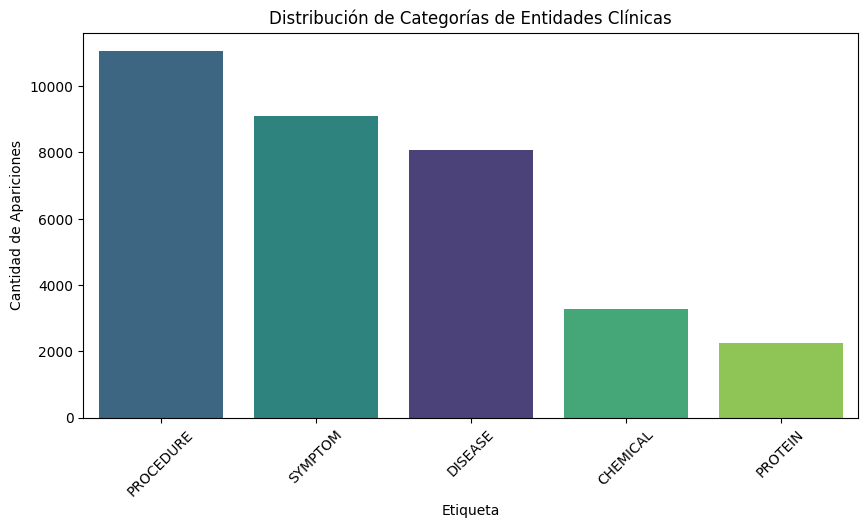


--- ESTADÍSTICAS DE PALABRAS POR ENTIDAD ---
count    33757.000000
mean         3.029268
std          3.035639
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         44.000000
Name: entity_word_count, dtype: float64


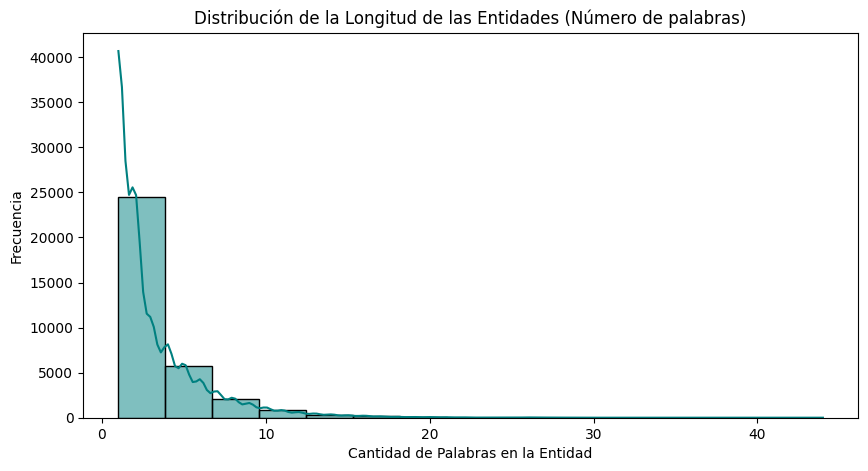


--- ESTADÍSTICAS DE ENTIDADES POR DOCUMENTO ---
count    750.000000
mean      45.009333
std       23.696032
min        9.000000
25%       28.000000
50%       40.500000
75%       57.000000
max      183.000000
dtype: float64


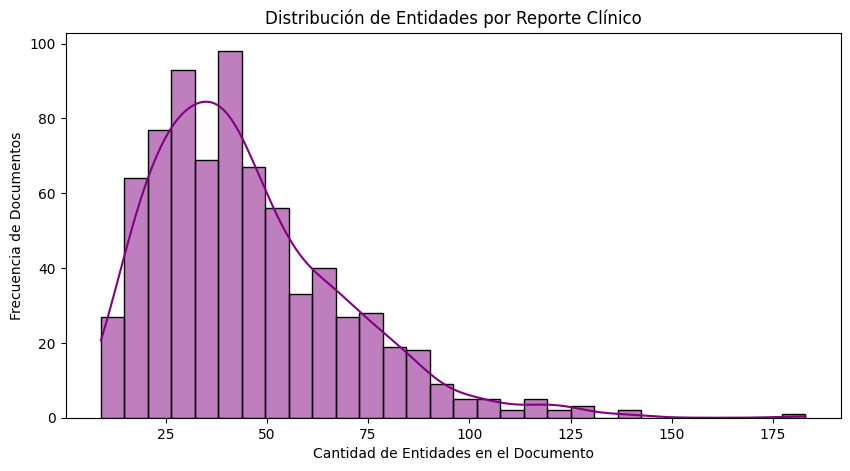

--- VERIFICACIÓN ESTRUCTURAL: TEST VS TRAIN ---
¿Las columnas son idénticas?: False
Columnas en Train: ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id', 'entity_word_count']
Columnas en Test:  ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id']

--- TIPOS DE DATOS EN TRAIN ---
filename             object
ann_id                int64
label                object
start_span            int64
end_span              int64
text                 object
doc_id               object
entity_word_count     int64
dtype: object

--- TIPOS DE DATOS EN TEST ---
filename      object
ann_id         int64
label         object
start_span     int64
end_span       int64
text          object
doc_id        object
dtype: object

Dimensiones Train (filas, columnas): (33757, 8)
Dimensiones Test (filas, columnas):  (11239, 7)


In [9]:


# 1. Inspección general
print("--- PRIMERAS 5 FILAS ---")
display(df_train.head())

print("\n--- VALORES NULOS ---")
print(df_train.isnull().sum())

# 2. Distribución de las clases / etiquetas de entidades
print("\n--- FRECUENCIA DE ETIQUETAS (LABELS) ---")
print(df_train['label'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_train, 
    x='label', 
    hue='label',
    order=df_train['label'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title('Distribución de Categorías de Entidades Clínicas')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad de Apariciones')
plt.xticks(rotation=45)
plt.show()

# 3. Análisis del tamaño de las entidades (número de palabras por entidad)
df_train['entity_word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

print("\n--- ESTADÍSTICAS DE PALABRAS POR ENTIDAD ---")
print(df_train['entity_word_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_train['entity_word_count'], bins=15, kde=True, color='teal')
plt.title('Distribución de la Longitud de las Entidades (Número de palabras)')
plt.xlabel('Cantidad de Palabras en la Entidad')
plt.ylabel('Frecuencia')
plt.show()

# 4. Análisis de densidad: ¿Cuántas entidades aparecen por cada documento clínico?
entities_per_file = df_train.groupby('filename').size()

print("\n--- ESTADÍSTICAS DE ENTIDADES POR DOCUMENTO ---")
print(entities_per_file.describe())

plt.figure(figsize=(10, 5))
sns.histplot(entities_per_file, bins=30, kde=True, color='purple')
plt.title('Distribución de Entidades por Reporte Clínico')
plt.xlabel('Cantidad de Entidades en el Documento')
plt.ylabel('Frecuencia de Documentos')
plt.show()




# Verificación estructural superficial
print("--- VERIFICACIÓN ESTRUCTURAL: TEST VS TRAIN ---")

# 1. Comparar columnas
columns_match = list(df_train.columns) == list(df_test.columns)
print(f"¿Las columnas son idénticas?: {columns_match}")
print(f"Columnas en Train: {df_train.columns.tolist()}")
print(f"Columnas en Test:  {df_test.columns.tolist()}")

# 2. Comparar tipos de datos (dtypes)
print("\n--- TIPOS DE DATOS EN TRAIN ---")
print(df_train.dtypes)

print("\n--- TIPOS DE DATOS EN TEST ---")
print(df_test.dtypes)

# 3. Verificación de dimensiones
print(f"\nDimensiones Train (filas, columnas): {df_train.shape}")
print(f"Dimensiones Test (filas, columnas):  {df_test.shape}")

- Distribución de Clases: encontramos un total de 33,757 entidades clínicas distribuidas en cinco categorías principales. PROCEDURE encabeza con 11,065 apariciones, seguida por SYMPTOM (9,091) y DISEASE (8,065). Las clases minoritarias corresponden a CHEMICAL (3,283) y PROTEIN (2,253). No encontramos valores nulos en ninguna columna, lo que valida la integridad de los datos descargados.

- La distribución de entidades presenta desbalance: PROCEDURE concentra el 32,78 % de las anotaciones, mientras PROTEIN representa solo el 6,68 %. Este desbalance puede favorecer el aprendizaje de las clases mayoritarias y reducir el recall de las minoritarias. Para mitigarlo se utilizarán pesos de clase en la función de pérdida y se reportarán métricas independientes por categoría.

- Longitud de las Entidades: observamos que la gran mayoría de las entidades médicas se concentran entre 1 y 3 palabras (con una media de 3.03 tokens por entidad). Sin embargo, existen casos complejos que alcanzan hasta 44 palabras. Esta variabilidad justifica nuestro uso de una red LSTM, ya que su arquitectura recurrente nos permite retener información de secuencias largas y capturar nombres clínicos compuestos extensos sin pérdida crítica de contexto.

- Densidad de Información por Documento: observamos un promedio de 45 entidades clínicas por cada reporte, con documentos que alcanzan un máximo de 183 menciones en un total de 750 archivos analizados. Esto confirma una alta densidad informativa por historia clínica, por lo que necesitamos que nuestro DataLoader gestione secuencias de texto amplias durante la vectorización con spaCy.

- Con la verificación estructural comprobamos que ambos conjuntos de datos, entrenamiento y prueba, son totalmente compatibles:

  Las columnas de entrenamiento y prueba son idénticas (filename, ann_id, label, start_span, end_span, text).

  Los tipos de datos coinciden de manera exacta en todos los campos, lo que nos garantiza que el pipeline de transformación que aplicamos al conjunto de entrenamiento funciona de forma idéntica en el conjunto de prueba sin errores de tipo.

  La proporción de los datos es coherente para un split de validación/prueba estándar en machine learning: contamos con 33,757 registros de entrenamiento y 11,239 registros de prueba.

  Con esta validación completada y libre de fugas de datos (data leakage), dejamos preparado el terreno para estructurar la transformación de los textos clínicos a nivel de documento y token.

### PASO 04 — Partición fija por documento

Seleccionamos los documentos oficiales de entrenamiento y separamos la validación usando `split_seed=42`. Hacemos la división por documento completo, nunca por filas de entidades, para evitar que texto del mismo caso aparezca en entrenamiento y validación. Guardamos una huella SHA-256 de la partición; las seis ejecuciones posteriores deben compartir exactamente esta huella. En la configuración completa usamos 600 documentos de train y 150 de validación.

In [10]:
# PASO 04 — Partición única compartida por ambas variantes (sin test)
# Mezclamos aleatoriamente los documentos de train oficiales (con split_seed fijo) y
# tomamos una fracción de ellos (CFG['fraction']); del resultado, el primer tramo
# (validation_fraction, 20% por defecto) queda como validación y el resto como
# entrenamiento. La partición es por documento completo (no por fila de entidad),
# y la reutilizan tanto la variante con_pos como sin_pos.
rng = np.random.default_rng(CFG['split_seed'])
order = rng.permutation(official_train_ids).tolist()
n_sample = min(len(order), max(5, math.ceil(len(order) * CFG['fraction'])))
selected = order[:n_sample]
n_val = max(1, round(n_sample * CFG['validation_fraction']))
val_ids, train_ids = sorted(selected[:n_val]), sorted(selected[n_val:])
assert train_ids and val_ids
assert not set(train_ids) & set(val_ids)
# Confirmamos que ningún texto de validación sea idéntico a uno de entrenamiento
# (evita fuga de datos aunque los identificadores de documento no coincidan).
assert not {fingerprint(texts[k]) for k in train_ids} & {fingerprint(texts[k]) for k in val_ids}
split_payload = {'train': train_ids, 'validation': val_ids, 'official_test': official_test_ids}
# Huella (hash) de la partición completa: nos permite comprobar, en los pasos
# siguientes, que las seis ejecuciones del PASO 09 usaron exactamente los mismos documentos.
split_sha256 = hashlib.sha256(json.dumps(split_payload, sort_keys=True).encode()).hexdigest()
REPORT['split'] = {'sample_documents': n_sample, 'train_documents': len(train_ids),
                   'validation_documents': len(val_ids), 'test_used_for_training': False,
                   'split_seed': CFG['split_seed'], 'sha256': split_sha256}
(RUN / 'split.json').write_text(json.dumps({**split_payload, 'split_seed': CFG['split_seed'], 'sha256': split_sha256}, indent=2), encoding='utf-8')
print('PASO 04 — MUESTRA:', json.dumps(REPORT['split'], indent=2))
print('Anotaciones por categoría en la muestra:')
print(df_train[df_train.doc_id.isin(selected)].label.value_counts().to_string())
print('PASO 04 OK. Ambas variantes usarán estos mismos documentos; todavía no comenzó a entrenar.')

PASO 04 — MUESTRA: {
  "sample_documents": 750,
  "train_documents": 600,
  "validation_documents": 150,
  "test_used_for_training": false,
  "split_seed": 42,
  "sha256": "ab06b4e8dd54e120c2fed93f276f1944a6e67c5227281778c38add2eea4dc497"
}
Anotaciones por categoría en la muestra:
label
PROCEDURE    11065
SYMPTOM       9091
DISEASE       8065
CHEMICAL      3283
PROTEIN       2253
PASO 04 OK. Ambas variantes usarán estos mismos documentos; todavía no comenzó a entrenar.


### PASO 05 — Tokenización, alineación y bloques BIO

Procesamos los documentos completos con spaCy en lotes, obtenemos tokens y POS, y alineamos los offsets de las anotaciones con esos tokens. Convertimos las entidades planas retenidas a etiquetas `B-*` e `I-*`; excluimos y contabilizamos las anotaciones anidadas, solapadas o no alineables. Dividimos cada documento en bloques sin truncar silenciosamente el texto y enmascaramos los tokens que no deben tratarse como negativos. Guardamos las características en caché para no repetir el preprocesamiento en ejecuciones posteriores.

In [12]:
# PASO 05 — POS por lotes, alineación BIO y bloques sin truncamiento
t0 = time.perf_counter()
nlp = spacy.load(CFG['spacy_model'], disable=['parser', 'ner', 'lemmatizer'])
REPORT['versions']['spacy_model'] = nlp.meta['version']
print('spaCy activo:', nlp.pipe_names, flush=True)

def make_examples(ids, annotations, split_name):
    """Convierte los documentos `ids` en ejemplos de entrenamiento con tokens, POS y
    etiquetas BIO, listos para el modelo. Por cada documento:

    1. Tokeniza con spaCy (ya corrido en lote) y obtiene el POS de cada token.
    2. Alinea cada anotación (offsets de caracter en el texto) con los tokens usando
       `char_span`; si una anotación no cae exactamente sobre límites de token, la
       descarta y la cuenta como 'unaligned'.
    3. Si dos anotaciones alineadas se solapan en tokens, conserva la más larga (y, en
       empate, la de inicio más temprano) y descarta el resto como 'overlap_excluded'.
       Esto es lo que hace el esquema "BIO plano": no admite entidades anidadas.
    4. Etiqueta los tokens de cada entidad conservada como `B-<label>` (primer token)
       e `I-<label>` (resto). Los tokens que pertenecían a una anotación descartada
       (no alineada o solapada) se marcan con `IGNORE`, para no castigarlos como
       negativos verdaderos ('O') durante el entrenamiento; los demás tokens sí quedan
       como 'O'.
    5. Divide cada documento en bloques de como máximo `CFG['max_tokens']` tokens, sin
       cortar el texto: si el corte natural cae en medio de una entidad (un token 'I-'
       justo después del límite), retrocede el corte hasta el inicio de esa entidad
       (o, si no puede, avanza hasta que la entidad termine) para no partirla.

    El resultado se guarda en caché en disco (la clave del archivo depende de los
    documentos, las anotaciones, la versión de spaCy y la política de alineación), de
    forma que si se vuelve a ejecutar esta PASO con los mismos datos no se repite este
    preprocesamiento, que es el más lento del cuaderno.

    Devuelve la lista de ejemplos (bloques) y un diccionario de estadísticas
    (documentos procesados, anotaciones retenidas/duplicadas/excluidas, tokens, etc.).
    """
    # Caché de features, ligada a textos, anotaciones, versión y política de alineación.
    subset = annotations[annotations.doc_id.isin(ids)]
    key = hashlib.sha256(json.dumps({'ids': ids, 'max_tokens': CFG['max_tokens'],
        'model': CFG['spacy_model'], 'version': nlp.meta['version'], 'spacy': spacy.__version__,
        'policy': 'flat-longest-strict-mask-v1',
        'texts': [fingerprint(texts[k]) for k in ids],
        'annotations': subset[['doc_id','start_span','end_span','label']].to_json()}
        , sort_keys=True).encode()).hexdigest()
    cache_file = CACHE / f'features_{key}.json'
    start = time.perf_counter()
    if cache_file.exists():
        payload = json.loads(cache_file.read_text(encoding='utf-8'))
        payload['stats']['cache_hit'] = True
        payload['stats']['seconds_this_run'] = time.perf_counter() - start
        (RUN / f'alignment_{split_name}.json').write_text(json.dumps(payload['stats'], indent=2), encoding='utf-8')
        return payload['examples'], payload['stats']
    groups = {k: g for k, g in subset.groupby('doc_id')}
    examples, excluded = [], []
    stats = Counter(documents=len(ids), annotations=0, duplicates=0, unaligned=0,
                    overlap_excluded=0, retained=0, tokens=0, ignored_tokens=0)
    retained_by_label = Counter()
    for key_id, doc in tqdm(zip(ids, nlp.pipe((texts[k] for k in ids), batch_size=16, n_process=1)),
                            total=len(ids), desc=f'POS y BIO {split_name}'):
        assert len(doc) > 0
        gold = [0] * len(doc)
        candidates, ignored_spans, seen = [], [], set()
        for row in groups[key_id].itertuples(index=False):
            a, b, label = int(row.start_span), int(row.end_span), row.label
            stats['annotations'] += 1
            identity = (a, b, label)
            if identity in seen:
                stats['duplicates'] += 1
                continue
            seen.add(identity)
            span = doc.char_span(a, b, alignment_mode='strict')
            if span is None:
                stats['unaligned'] += 1
                ignored_spans.append((a, b))
                excluded.append({'doc_id': key_id, 'start': a, 'end': b, 'label': label, 'reason': 'unaligned'})
            else:
                candidates.append((a, b, label, span.start, span.end))
        # Resolvemos solapes eligiendo primero las entidades más largas (y, en empate,
        # las que empiezan antes); una vez asignados sus tokens en `gold`, cualquier
        # candidata que se solape con una ya asignada se descarta.
        for a, b, label, i, j in sorted(candidates, key=lambda x: (-(x[1]-x[0]), x[0], x[2])):
            if any(gold[k] != 0 for k in range(i, j)):
                stats['overlap_excluded'] += 1
                ignored_spans.append((a, b))
                excluded.append({'doc_id': key_id, 'start': a, 'end': b, 'label': label, 'reason': 'overlap'})
                continue
            gold[i] = tag_to_ix[f'B-{label}']
            gold[i+1:j] = [tag_to_ix[f'I-{label}']] * (j-i-1)
            stats['retained'] += 1
            retained_by_label[label] += 1
        # Los tokens de anotaciones descartadas no son negativos O, salvo que otra
        # entidad retenida ya les haya asignado una etiqueta válida.
        for token in doc:
            if gold[token.i] == 0 and any(token.idx < b and token.idx + len(token) > a for a, b in ignored_spans):
                gold[token.i] = IGNORE
        words = [token.text for token in doc]
        pos = [pos_to_ix.get(token.pos_, 1) for token in doc]
        stats['tokens'] += len(doc)
        stats['ignored_tokens'] += gold.count(IGNORE)
        start_token = 0
        while start_token < len(doc):
            end = min(start_token + CFG['max_tokens'], len(doc))
            # Si el siguiente token es I-, el corte cae dentro de una entidad.
            if end < len(doc) and gold[end] >= 0 and TAGS[gold[end]].startswith('I-'):
                # Primero intentamos retroceder el corte hasta el inicio de esa entidad
                # (para no partirla); si el bloque quedaría vacío, en su lugar avanzamos
                # el corte hasta que la entidad termine.
                cut = end
                while cut > start_token and gold[cut] >= 0 and TAGS[gold[cut]].startswith('I-'):
                    cut -= 1
                if cut > start_token:
                    end = cut
                else:
                    while end < len(doc) and gold[end] >= 0 and TAGS[gold[end]].startswith('I-'):
                        end += 1
            assert end > start_token
            examples.append({'doc_id': key_id, 'start_token': start_token, 'tokens': words[start_token:end],
                             'pos': pos[start_token:end], 'labels': gold[start_token:end]})
            start_token = end
    stats = dict(stats)
    stats.update(retained_by_label=dict(retained_by_label), cache_hit=False,
                 sequences=len(examples), seconds_this_run=time.perf_counter() - start,
                 excluded_examples=excluded[:20])
    assert sum(len(e['tokens']) for e in examples) == stats['tokens'], 'Se perdieron tokens.'
    assert stats.get('retained', 0) > 0, 'No quedaron entidades. Comparte este error.'
    payload = {'examples': examples, 'stats': stats}
    cache_file.write_text(json.dumps(payload, ensure_ascii=False), encoding='utf-8')
    (RUN / f'alignment_{split_name}.json').write_text(json.dumps(stats, indent=2), encoding='utf-8')
    return examples, stats

train_examples, train_stats = make_examples(train_ids, df_train, 'train')
val_examples, val_stats = make_examples(val_ids, df_train, 'validation')
REPORT['alignment'] = {'train': train_stats, 'validation': val_stats}
REPORT['preprocessing_seconds'] = time.perf_counter() - t0
for name, stats in REPORT['alignment'].items():
    print(name, json.dumps({k:v for k,v in stats.items() if k != 'excluded_examples'}, indent=2))
print('PASO 05 OK. Detalle de exclusiones en alignment_*.json.')

spaCy activo: ['tok2vec', 'morphologizer', 'attribute_ruler']
train {
  "documents": 600,
  "annotations": 26849,
  "duplicates": 0,
  "unaligned": 197,
  "overlap_excluded": 4251,
  "retained": 22401,
  "tokens": 242172,
  "ignored_tokens": 943,
  "retained_by_label": {
    "SYMPTOM": 6325,
    "DISEASE": 5866,
    "PROCEDURE": 7253,
    "PROTEIN": 1090,
    "CHEMICAL": 1867
  },
  "cache_hit": true,
  "sequences": 2204,
  "seconds_this_run": 0.09307989099988845
}
validation {
  "documents": 150,
  "annotations": 6908,
  "duplicates": 0,
  "unaligned": 57,
  "overlap_excluded": 990,
  "retained": 5861,
  "tokens": 62994,
  "ignored_tokens": 277,
  "retained_by_label": {
    "PROCEDURE": 1906,
    "DISEASE": 1391,
    "SYMPTOM": 1682,
    "CHEMICAL": 577,
    "PROTEIN": 305
  },
  "cache_hit": true,
  "sequences": 562,
  "seconds_this_run": 0.02381061400001272
}
PASO 05 OK. Detalle de exclusiones en alignment_*.json.


### PASO 06 — Vocabulario, lotes y función de pérdida

Construimos el vocabulario de palabras usando solo los bloques de entrenamiento; las palabras nuevas de validación pasan a `<UNK>`. Definimos el padding dinámico, los `DataLoader` y los pesos moderados por clase. `O` es una etiqueta válida que la red aprende; solo usamos `IGNORE=-100` para el padding y las posiciones no evaluables. Con la función `loss_parts` impedimos continuar con un lote sin etiquetas válidas y evitamos ocultar errores mediante pérdidas `NaN`.

In [13]:
# PASO 06 — Vocabulario solo de train; padding dinámico y pesos moderados
counts = Counter(token for e in train_examples for token in e['tokens'])
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
for token in sorted(counts, key=lambda w: (-counts[w], w)):
    if token not in word_to_ix:
        word_to_ix[token] = len(word_to_ix)

class ClinicalDataset(Dataset):
    """Dataset de PyTorch que envuelve los bloques (ejemplos) generados en el PASO 05.
    Convierte cada bloque a tensores de índices: palabras (según `word_to_ix`, con
    `<UNK>`=1 para palabras no vistas en entrenamiento), POS y etiquetas BIO."""
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        e = self.examples[idx]
        return (torch.tensor([word_to_ix.get(w, 1) for w in e['tokens']], dtype=torch.long),
                torch.tensor(e['pos'], dtype=torch.long), torch.tensor(e['labels'], dtype=torch.long))

def collate(batch):
    """Función de collate del DataLoader: junta una lista de ejemplos de distinta
    longitud en un solo lote, aplicando padding dinámico (cada lote se rellena solo
    hasta la longitud de su secuencia más larga, no hasta `max_tokens`). Además de las
    secuencias rellenadas, devuelve `lengths` con el largo real de cada secuencia, que
    la LSTM necesita para no procesar el padding como si fuera texto real."""
    words, pos, labels = zip(*batch)
    return {'input_ids': pad_sequence(words, batch_first=True, padding_value=0),
            'pos_ids': pad_sequence(pos, batch_first=True, padding_value=0),
            'labels': pad_sequence(labels, batch_first=True, padding_value=IGNORE),
            'lengths': torch.tensor([len(w) for w in words], dtype=torch.long)}

train_dataset, val_dataset = ClinicalDataset(train_examples), ClinicalDataset(val_examples)
generator = torch.Generator().manual_seed(CFG['training_seeds'][0])
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          collate_fn=collate, num_workers=0, generator=generator, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_dataset, batch_size=CFG['batch_size'], shuffle=False,
                        collate_fn=collate, num_workers=0, pin_memory=(device.type == 'cuda'))
label_counts = Counter(y for e in train_examples for y in e['labels'] if y != IGNORE)
assert label_counts[0] > 0 and sum(v for k,v in label_counts.items() if k > 0) > 0
weights = torch.ones(len(TAGS))
if CFG['class_weights']:
    # Pesos inversamente proporcionales a la frecuencia de cada etiqueta (suavizados con
    # raíz cuadrada y acotados entre 0.25 y 5) para que la clase mayoritaria 'O' no
    # domine la pérdida frente a las etiquetas de entidad, mucho más escasas.
    freq = torch.tensor([label_counts[i] for i in range(len(TAGS))], dtype=torch.float)
    present = freq > 0
    weights[present] = (freq[present].sum() / (present.sum() * freq[present])).sqrt().clamp(0.25, 5.0)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=IGNORE, reduction='none').to(device)

def loss_parts(logits, labels):
    """Calcula la pérdida de entropía cruzada ponderada por clase, ignorando las
    posiciones marcadas con `IGNORE` (padding y anotaciones descartadas). En vez de
    devolver directamente el promedio, devuelve el numerador (suma de pérdidas) y el
    denominador (suma de pesos) por separado, para poder acumularlos correctamente a
    través de varios lotes de distinto tamaño (por ejemplo, en el reporte de la época).
    Lanza un error si el lote no tiene ninguna etiqueta válida, en vez de omitirlo en
    silencio, para no ocultar un problema de alineación de datos."""
    valid = labels != IGNORE
    if not valid.any():
        raise RuntimeError('Lote sin etiquetas válidas: revisar alineación, no omitirlo silenciosamente.')
    losses = criterion(logits.reshape(-1, len(TAGS)), labels.reshape(-1))
    numerator = losses.sum()
    denominator = weights[labels[valid]].sum()
    return numerator / denominator, numerator, denominator

val_tokens = [w for e in val_examples for w in e['tokens']]
REPORT['vocabulary'] = {'size': len(word_to_ix),
    'validation_unknown_fraction': sum(w not in word_to_ix for w in val_tokens) / len(val_tokens),
    'train_tag_counts': {TAGS[k]: v for k,v in sorted(label_counts.items())},
    'missing_train_tags': [TAGS[i] for i in range(len(TAGS)) if label_counts[i] == 0]}
(RUN / 'vocabulary.json').write_text(json.dumps({'words': word_to_ix, 'pos': pos_to_ix,
    'tags': tag_to_ix, 'ignore_index': IGNORE}, ensure_ascii=False), encoding='utf-8')
print('PASO 06 OK:', json.dumps(REPORT['vocabulary'], indent=2))
if REPORT['vocabulary']['missing_train_tags']:
    print('AVISO: faltan etiquetas en esta muestra; la prueba no permite valorar esas etiquetas.')

PASO 06 OK: {
  "size": 20295,
  "validation_unknown_fraction": 0.054703622567228626,
  "train_tag_counts": {
    "O": 167635,
    "B-CHEMICAL": 1867,
    "I-CHEMICAL": 251,
    "B-DISEASE": 5866,
    "I-DISEASE": 13097,
    "B-PROCEDURE": 7253,
    "I-PROCEDURE": 16851,
    "B-PROTEIN": 1090,
    "I-PROTEIN": 336,
    "B-SYMPTOM": 6325,
    "I-SYMPTOM": 20658
  },
  "missing_train_tags": []
}


### PASO 07 — Arquitecturas y métricas

Definimos la Bi-LSTM bidireccional con embeddings de palabras y, cuando `use_pos=True`, embeddings POS concatenados. En la variante `use_pos=False` eliminamos realmente la entrada POS para usarla como control experimental. Con la función de evaluación calculamos la coincidencia exacta de entidades por límites y categoría, además de precisión, recall, F1 y exactitud por token. Reparamos las transiciones `I-*` ilegales solo al medir y las contamos como diagnóstico.

In [14]:
# PASO 07 — Bi-LSTM GPU T4 ×2 y métricas estrictas de entidades (BIO plano)
class ClinicalBiLSTM(nn.Module):
    """Red para etiquetado de secuencias BIO. Combina un embedding de palabra con,
    opcionalmente (`use_pos=True`), un embedding de POS concatenado; pasa la secuencia
    resultante por una LSTM bidireccional y proyecta cada salida a un logit por cada
    etiqueta posible en `TAGS`. Con `use_pos=False` la entrada POS ni siquiera se crea
    (`pos_embedding=None`), por lo que sirve de control experimental real y no solo de
    bandera ignorada."""
    def __init__(self, use_pos=True):
        super().__init__()
        self.word_embedding = nn.Embedding(len(word_to_ix), CFG['embedding_dim'], padding_idx=0)
        self.use_pos = bool(use_pos)
        self.pos_embedding = nn.Embedding(len(POS), CFG['pos_dim'], padding_idx=0) if self.use_pos else None
        self.dropout = nn.Dropout(CFG['dropout'])
        self.lstm = nn.LSTM(CFG['embedding_dim'] + (CFG['pos_dim'] if self.use_pos else 0), CFG['hidden_dim'],
            num_layers=CFG['layers'], bidirectional=True, batch_first=True,
            dropout=CFG['dropout'] if CFG['layers'] > 1 else 0)
        self.fc = nn.Linear(2 * CFG['hidden_dim'], len(TAGS))
    def forward(self, input_ids, pos_ids, lengths):
        """Calcula los logits de cada token del lote. Empaqueta la secuencia
        (`pack_padded_sequence`) para que la LSTM no procese el padding como si fuera
        texto real, y luego la desempaqueta indicando `total_length` (el ancho del lote
        de entrada) para que todas las réplicas de `DataParallel` devuelvan tensores del
        mismo tamaño y puedan volver a juntarse en un solo tensor."""
        x = self.word_embedding(input_ids)
        if self.use_pos:
            x = torch.cat([x, self.pos_embedding(pos_ids)], dim=-1)
        x = self.dropout(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, _ = self.lstm(packed)
        # total_length común permite reunir réplicas con longitudes máximas distintas.
        output, _ = pad_packed_sequence(output, batch_first=True, total_length=input_ids.shape[1])
        return self.fc(self.dropout(output))

def entity_spans(tag_ids):
    """Agrupa una secuencia de índices de etiqueta BIO en entidades completas
    `(inicio, fin, categoría)`. Recorre los índices y va extendiendo la entidad activa
    mientras encuentra `I-<misma categoría>`; en cualquier otro caso cierra la entidad
    activa (si había una) y, si el tag es `B-` o `I-`, abre una nueva.

    Una `I-` que aparece sin una entidad activa de la misma categoría es una transición
    BIO ilegal (no debería pasar en las etiquetas reales, pero sí puede pasar en las
    predicciones del modelo); en ese caso, en vez de descartarla, la tratamos igual como
    inicio de una nueva entidad (reparación determinista) y contamos cuántas veces
    ocurrió esto en `invalid`.

    Devuelve el conjunto de entidades encontradas y el número de transiciones
    inválidas reparadas."""
    # Una I- ilegal inicia entidad (reparación determinista); se cuenta por separado.
    result, active, begin, invalid = set(), None, None, 0
    for i, idx in enumerate(list(tag_ids) + [0]):
        tag = TAGS[idx] if idx >= 0 else 'O'
        prefix, label = tag.split('-', 1) if tag != 'O' else ('O', None)
        continuing = prefix == 'I' and label == active
        if active is not None and not continuing:
            result.add((begin, i, active)); active = None
        if prefix in ('B', 'I') and not continuing:
            invalid += int(prefix == 'I')
            begin, active = i, label
    return result, invalid

def scores_from_counts(tp, predicted, gold):
    """Calcula precisión, recall y F1 a partir de conteos agregados: verdaderos
    positivos (`tp`), total de entidades predichas (`predicted`) y total de entidades
    reales (`gold`)."""
    precision = tp / predicted if predicted else 0.0
    recall = tp / gold if gold else 0.0
    return {'precision': precision, 'recall': recall,
            'f1': 2*precision*recall/(precision+recall) if precision+recall else 0.0,
            'support': gold, 'predicted': predicted}

@torch.no_grad()
def evaluate(model, loader):
    """Evalúa el modelo sobre un DataLoader completo, en modo inferencia.
    Por cada lote: acumula la pérdida (para reportarla) y la exactitud por token, y
    reconstruye las entidades predichas y reales con `entity_spans` para comparar
    coincidencia EXACTA de límites y categoría (no basta con acertar tokens sueltos).
    Acumula verdaderos positivos/predichos/reales por categoría (`per_label`) y en
    total (`micro`), y cuenta las transiciones BIO inválidas que tuvo que reparar
    `entity_spans` en las predicciones (en el gold no debería haber ninguna, por eso
    se afirma con `assert`).

    Devuelve un diccionario con la pérdida, las métricas micro y por categoría, la
    exactitud por token y el conteo de transiciones inválidas."""
    model.eval()
    totals = {label: Counter() for label in LABELS}
    numerator = denominator = correct = tokens = invalid = 0
    for batch in loader:
        batch = move_batch(batch)
        logits = model(batch['input_ids'], batch['pos_ids'], batch['lengths'])
        _, num, den = loss_parts(logits, batch['labels'])
        numerator += num.item(); denominator += den.item()
        pred = logits.argmax(-1)
        mask = batch['labels'] != IGNORE
        correct += ((pred == batch['labels']) & mask).sum().item(); tokens += mask.sum().item()
        for p, g, length in zip(pred.tolist(), batch['labels'].tolist(), batch['lengths'].tolist()):
            g = g[:length]; p = p[:length]
            # Mantener posiciones; no unir entidades a través de huecos ignorados.
            p = [x if y != IGNORE else 0 for x, y in zip(p, g)]
            g = [y if y != IGNORE else 0 for y in g]
            ps, errors = entity_spans(p); gs, gold_errors = entity_spans(g)
            assert gold_errors == 0, 'BIO gold inválido.'
            invalid += errors
            for label in LABELS:
                totals[label].update(tp=sum(x[2] == label for x in ps & gs),
                    predicted=sum(x[2] == label for x in ps), gold=sum(x[2] == label for x in gs))
    per_label = {k: scores_from_counts(v['tp'], v['predicted'], v['gold']) for k,v in totals.items()}
    micro = scores_from_counts(sum(v['tp'] for v in totals.values()),
                               sum(v['predicted'] for v in totals.values()), sum(v['gold'] for v in totals.values()))
    return {'loss': numerator / denominator, 'micro': micro, 'per_label': per_label,
            'token_accuracy': correct / tokens, 'invalid_bio_transitions': invalid}

print('PASO 07 OK. Modelo definido; aún no se ha entrenado.')

PASO 07 OK. Modelo definido; aún no se ha entrenado.


### PASO 08 — Prueba técnica de las dos variantes

Antes de invertir tiempo en los seis entrenamientos, creamos modelos temporales con y sin POS. Comprobamos que la pérdida baje al repetir un lote, que existan gradientes finitos, que el padding no cambie las salidas y que funcionen lotes pequeños o con longitudes distintas. También registramos los dispositivos usados: `cuda:0` y `cuda:1`. Si esta PASO falla, no continúes con el PASO 09; comparte el bloque `ERROR_PARA_COMPARTIR`.

In [15]:
# PASO 08 — PRUEBA TÉCNICA: ambas GPU, gradientes, padding y lote desigual
# Modelo temporal: sus pesos NO pasan al entrenamiento de el PASO 09.
def run_smoke_test(use_pos):
    """Prueba técnica rápida (no es el entrenamiento real) que valida, antes de
    invertir tiempo en los seis entrenamientos de el PASO 09:

    - Que la pérdida efectivamente baja al repetir 20 veces el mismo lote pequeño
      (si no bajara, algo estaría mal en el modelo, la pérdida o el optimizador).
    - Que los gradientes son finitos y no nulos (no hay NaN/Inf ni un modelo que no
      aprende nada).
    - Que ambas GPU configuradas participan realmente del cómputo, verificado con un
      hook que registra en qué dispositivo se ejecutó la capa final (`fc`).
    - Que el resultado no cambia si se agrega padding extra a la derecha de la
      entrada (invariancia al padding: importante porque distintos lotes tienen
      distinto largo máximo).
    - En la variante sin POS, que cambiar `pos_ids` no afecta la salida, confirmando
      que en verdad se ignoran (y no que `use_pos=False` sea solo una bandera cosmética).
    - Que el modelo produce el mismo resultado con lotes más pequeños o de tamaño
      desigual (como puede ocurrir con el último lote de una época).

    Los pesos de este modelo temporal se descartan al terminar la prueba; nunca pasan
    al entrenamiento real de el PASO 09."""
    import threading
    synchronize_devices()
    t0 = time.perf_counter()
    probe_batch = move_batch(collate([train_dataset[i] for i in range(min(4, len(train_dataset)))]))
    torch.manual_seed(CFG['training_seeds'][0])
    if device_ids:
        torch.cuda.manual_seed_all(CFG['training_seeds'][0])
    base = ClinicalBiLSTM(use_pos=use_pos)
    # cuDNN necesita modo train para backward de la LSTM. Desactivar solo dropout.
    for module in base.modules():
        if isinstance(module, nn.Dropout): module.p = 0.0
        if isinstance(module, nn.LSTM): module.dropout = 0.0
    observed, lock = set(), threading.Lock()
    def record_device(module, inputs, output):
        """Hook de forward que registra en qué dispositivo (por ejemplo 'cuda:0' o
        'cuda:1') se ejecutó la capa, para comprobar que DataParallel efectivamente
        repartió el lote entre todas las GPU configuradas."""
        with lock:
            observed.add(str(output.device))
    handle = base.fc.register_forward_hook(record_device)
    probe = prepare_model(base)
    probe.train()
    probe_optimizer = torch.optim.Adam(probe.parameters(), lr=0.01)
    losses = []
    for step in range(20):
        probe_optimizer.zero_grad(set_to_none=True)
        logits = probe(probe_batch['input_ids'], probe_batch['pos_ids'], probe_batch['lengths'])
        loss, _, _ = loss_parts(logits, probe_batch['labels'])
        assert torch.isfinite(loss), 'Pérdida no finita en prueba técnica.'
        loss.backward()
        norm = torch.nn.utils.clip_grad_norm_(probe.parameters(), 1.0, error_if_nonfinite=True)
        assert norm > 0, 'Gradiente nulo: revisar etiquetas.'
        probe_optimizer.step()
        losses.append(loss.item())
    handle.remove()
    expected = {f'cuda:{i}' for i in device_ids} if device_ids else {'cpu'}
    assert observed == expected, f'GPU ejecutadas: {observed}; esperadas: {expected}.'
    assert min(losses[-5:]) < losses[0], 'La pérdida no bajó al repetir el lote.'
    probe.eval()
    with torch.no_grad():
        original = probe(probe_batch['input_ids'], probe_batch['pos_ids'], probe_batch['lengths'])
        if not use_pos:
            assert unwrap(probe).pos_embedding is None
            changed_pos = (probe_batch['pos_ids'] + 1) % len(POS)
            without_pos = probe(probe_batch['input_ids'], changed_pos, probe_batch['lengths'])
            torch.testing.assert_close(original, without_pos, atol=1e-5, rtol=1e-4)
        padded = probe(torch.nn.functional.pad(probe_batch['input_ids'], (0, 7)),
                       torch.nn.functional.pad(probe_batch['pos_ids'], (0, 7)), probe_batch['lengths'])
        torch.testing.assert_close(original, padded[:, :original.shape[1]], atol=1e-5, rtol=1e-4)
        # Simular longitudes máximas diferentes por réplica y un último lote pequeño.
        for size in (1, 3, 4):
            size = min(size, len(probe_batch['lengths']))
            words, pos = probe_batch['input_ids'][:size], probe_batch['pos_ids'][:size]
            lengths = torch.minimum(probe_batch['lengths'][:size],
                                    torch.arange(1, size+1, device=device))
            parallel = probe(words, pos, lengths)
            single = unwrap(probe)(words, pos, lengths)
            assert parallel.shape == (size, words.shape[1], len(TAGS))
            torch.testing.assert_close(parallel, single, atol=1e-5, rtol=1e-4)
    synchronize_devices()
    return {'passed': True, 'steps': len(losses), 'initial_loss': losses[0], 'final_loss': losses[-1],
            'seconds': time.perf_counter()-t0, 'padding_invariant': True,
            'uneven_batches_passed': True, 'executed_devices': sorted(observed),
            'multi_gpu_verified': len(device_ids) > 1, 'use_pos': use_pos,
            'pos_ignored_verified': not use_pos}

try:
    smoke_results = {name: run_smoke_test(use_pos) for name, use_pos in [('con_pos', True), ('sin_pos', False)]}
    REPORT['smoke_test'] = {'passed': all(r['passed'] for r in smoke_results.values()),
                            'variants': smoke_results}
except Exception as exc:
    failure = {'status': 'ERROR', 'cell': '08', 'error': str(exc), 'gpu': gpu_info,
               'traceback': traceback.format_exc()}
    (RUN / 'error.json').write_text(json.dumps(failure, indent=2), encoding='utf-8')
    print('ERROR_PARA_COMPARTIR', json.dumps(failure, indent=2), flush=True)
    raise
print('PASO 08 OK:', json.dumps(REPORT['smoke_test'], indent=2))


PASO 08 OK: {
  "passed": true,
  "variants": {
    "con_pos": {
      "passed": true,
      "steps": 20,
      "initial_loss": 2.3913092613220215,
      "final_loss": 0.02007252350449562,
      "seconds": 6.062303176000114,
      "padding_invariant": true,
      "uneven_batches_passed": true,
      "executed_devices": [
        "cuda:0",
        "cuda:1"
      ],
      "multi_gpu_verified": true,
      "use_pos": true,
      "pos_ignored_verified": false
    },
    "sin_pos": {
      "passed": true,
      "steps": 20,
      "initial_loss": 2.4176409244537354,
      "final_loss": 0.040876299142837524,
      "seconds": 0.450554049999937,
      "padding_invariant": true,
      "uneven_batches_passed": true,
      "executed_devices": [
        "cuda:0",
        "cuda:1"
      ],
      "multi_gpu_verified": true,
      "use_pos": false,
      "pos_ignored_verified": true
    }
  }
}


### PASO 09 — Seis entrenamientos independientes

Ejecutamos dos arquitecturas (`con_pos` y `sin_pos`) para cada semilla de `training_seeds`. En cada corrida reiniciamos pesos, optimizador, generadores aleatorios y estadísticas de GPU, pero conservamos la misma partición, vocabulario y lotes base. Entrenamos hasta el máximo de épocas o hasta la parada temprana, seleccionamos el mejor checkpoint por F1 de validación y guardamos historial, métricas y pesos en `seed_*/con_pos/` y `seed_*/sin_pos/`. 

In [ ]:
# PASO 09 — SEIS ENTRENAMIENTOS: cada semilla con POS y sin POS, dos T4 por ejecución
assert REPORT.get('smoke_test', {}).get('passed'), 'Ejecuta primero el PASO 08.'

def train_variant(name, use_pos, training_seed):
    """Entrena una variante del modelo (`name` es 'con_pos' o 'sin_pos') para una
    semilla (`training_seed`) específica, de principio a fin:

    1. Reinicia las semillas aleatorias (random, numpy, torch, CUDA) y las estadísticas
       de memoria de GPU, para que cada una de las seis corridas sea independiente y
       reproducible a partir de su propia semilla.
    2. Crea un modelo nuevo (`ClinicalBiLSTM`) y su optimizador Adam.
    3. Entrena hasta `CFG['epochs']` épocas; al final de cada época evalúa en
       validación (`evaluate`) y guarda el checkpoint solo si mejora el F1 de
       validación respecto al mejor visto hasta ahora (o, en empate de F1, si baja la
       pérdida de validación).
    4. Aplica parada temprana: si pasan `CFG['patience']` épocas seguidas sin mejorar,
       detiene el entrenamiento antes de llegar al máximo de épocas.
    5. Si ocurre un error durante el entrenamiento, guarda un reporte (`error.json`)
       con el historial parcial antes de volver a lanzar la excepción (para no perder
       el progreso ya hecho al depurar el problema).
    6. Al terminar, recarga el mejor checkpoint guardado (no el último), vuelve a
       evaluarlo en validación y guarda el resultado final (`result.json`).

    Devuelve un diccionario con el número de parámetros, el historial de épocas, las
    métricas finales de validación, la mejor época y la ruta del checkpoint."""
    random.seed(training_seed); np.random.seed(training_seed)
    variant_dir = RUN / f'seed_{training_seed}' / name
    variant_dir.mkdir(parents=True, exist_ok=True)
    result = {'variant': name, 'use_pos': use_pos, 'seed': training_seed, 'split_sha256': split_sha256,
              'checkpoint': str(variant_dir / 'best_model.pt')}
    torch.manual_seed(training_seed)
    generator.manual_seed(training_seed)
    if device_ids:
        torch.cuda.manual_seed_all(training_seed)
    for index in device_ids:
        torch.cuda.reset_peak_memory_stats(index)
    model = prepare_model(ClinicalBiLSTM(use_pos=use_pos))
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['learning_rate'])
    result['parameters'] = sum(p.numel() for p in model.parameters())
    history, best_f1, best_loss, stale = [], -1.0, float('inf'), 0
    best_path = variant_dir / 'best_model.pt'
    print(f'Semilla {training_seed}, variante {name}. Inicio: {device}, GPU utilizadas={device_ids}, {result["parameters"]:,} parámetros, {len(train_dataset)} bloques train, '
          f'{len(val_dataset)} bloques validación. Fracción={CFG["fraction"]:.0%}', flush=True)
    try:
        for epoch in range(1, CFG['epochs'] + 1):
            synchronize_devices()
            t0 = time.perf_counter()
            model.train()
            num_sum = den_sum = updates = 0
            for batch in tqdm(train_loader, desc=f'seed={training_seed} {name} - Época {epoch}/{CFG["epochs"]}'):
                batch = move_batch(batch)
                optimizer.zero_grad(set_to_none=True)
                logits = model(batch['input_ids'], batch['pos_ids'], batch['lengths'])
                loss, num, den = loss_parts(logits, batch['labels'])
                if not torch.isfinite(loss):
                    raise RuntimeError(f'Pérdida no finita, época {epoch}, actualización {updates}.')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
                optimizer.step()
                num_sum += num.item(); den_sum += den.item(); updates += 1
            synchronize_devices()
            train_seconds = time.perf_counter() - t0
            t1 = time.perf_counter()
            validation = evaluate(model, val_loader)
            synchronize_devices()
            row = {'variant': name, 'seed': training_seed, 'epoch': epoch, 'train_loss': num_sum/den_sum, 'validation_loss': validation['loss'],
                   'validation_f1': validation['micro']['f1'], 'updates': updates,
                   'train_seconds': train_seconds, 'validation_seconds': time.perf_counter()-t1,
                   'gpu_memory': memory_report()}
            history.append(row)
            print('RESULTADO_EPOCA', json.dumps(row), flush=True)
            improved = (row['validation_f1'] > best_f1 or
                        (row['validation_f1'] == best_f1 and row['validation_loss'] < best_loss))
            if improved:
                best_f1, best_loss, stale = row['validation_f1'], row['validation_loss'], 0
                torch.save({'state_dict': {k: v.detach().cpu() for k, v in unwrap(model).state_dict().items()}, 'config': CFG.copy(), 'epoch': epoch, 'use_pos': use_pos, 'variant': name, 'training_seed': training_seed, 'split_sha256': split_sha256,
                            'word_to_ix': word_to_ix, 'pos_to_ix': pos_to_ix, 'tag_to_ix': tag_to_ix}, best_path)
            else:
                stale += 1
            (variant_dir / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
            if stale >= CFG['patience']:
                print('Parada temprana: validación no mejoró.'); break
    except Exception as exc:
        failure = {'status': 'ERROR', 'cell': '09', 'variant': name, 'seed': training_seed, 'error': str(exc), 'history': history,
                   'traceback': traceback.format_exc(), 'gpu': gpu_info}
        (variant_dir / 'error.json').write_text(json.dumps(failure, indent=2), encoding='utf-8')
        print('ERROR_PARA_COMPARTIR', json.dumps(failure, indent=2), flush=True)
        raise
    checkpoint = torch.load(best_path, map_location='cpu', weights_only=True)
    unwrap(model).load_state_dict(checkpoint['state_dict'])
    result['gpu_peak_memory'] = memory_report()
    result['history'] = history
    result['best_epoch'] = checkpoint['epoch']
    result['validation'] = evaluate(model, val_loader)
    result['train_seconds_total'] = sum(r['train_seconds'] for r in history)
    result['validation_seconds_total'] = sum(r['validation_seconds'] for r in history)
    result['epochs_completed'] = len(history)
    (variant_dir / 'result.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result

# Verificar que las listas no cambiaron desde el PASO 04.
assert hashlib.sha256(json.dumps({'train': train_ids, 'validation': val_ids,
    'official_test': official_test_ids}, sort_keys=True).encode()).hexdigest() == split_sha256
REPORT['experiments'] = {}
for training_seed in CFG['training_seeds']:
    pair = {}
    REPORT['experiments'][str(training_seed)] = pair
    for variant_name, use_pos in [('con_pos', True), ('sin_pos', False)]:
        pair[variant_name] = train_variant(variant_name, use_pos, training_seed)
        # Conservar avances si una ejecución posterior falla.
        (RUN / 'experiments_progress.json').write_text(json.dumps(REPORT['experiments'], indent=2), encoding='utf-8')
print(f'CELDA 09 OK. Terminaron {2 * len(CFG["training_seeds"])} entrenamientos. Ejecuta la CELDA 10.')


### PASO 10 — Agregación y resumen para compartir

Resumimos los seis entrenamientos sin volver a entrenar. Calculamos F1, precisión y recall por semilla, medias y desviaciones estándar muestrales por variante, diferencias pareadas con POS menos sin POS y resultados por categoría. 

In [64]:
# PASO 10 — MEDIA, DESVIACIÓN ESTÁNDAR, DIFERENCIAS PAREADAS Y RESUMEN
experiments = REPORT.get('experiments', {})
assert set(experiments) == {str(s) for s in CFG['training_seeds']}, 'Faltan semillas: completa el PASO 09.'
assert all(set(pair) == {'con_pos', 'sin_pos'} for pair in experiments.values()), 'Falta alguna variante.'
# Por cada semilla y variante armamos una fila con las métricas de validación
# (rows), otra fila por categoría (label_rows) y una fila con la diferencia
# con_pos - sin_pos de esa semilla (paired_rows), para poder comparar de forma
# pareada (misma semilla, misma partición, distinta variante).
rows, label_rows, paired_rows = [], [], []
gold_support = None
for seed in CFG['training_seeds']:
    pair = experiments[str(seed)]
    for name, result in pair.items():
        assert result['seed'] == seed and result['split_sha256'] == REPORT['split']['sha256']
        metrics = result['validation']['micro']
        if gold_support is None: gold_support = metrics['support']
        assert metrics['support'] == gold_support, 'Las ejecuciones no evalúan el mismo gold.'
        rows.append({'semilla': seed, 'variante': name, 'parametros': result['parameters'],
            'mejor_epoca': result['best_epoch'], 'epocas_ejecutadas': result['epochs_completed'],
            'precision_pct': 100*metrics['precision'], 'recall_pct': 100*metrics['recall'],
            'f1_pct': 100*metrics['f1'], 'train_segundos': result['train_seconds_total'],
            'validacion_segundos': result['validation_seconds_total'],
            'segundos_medianos_por_epoca': float(np.median([r['train_seconds'] for r in result['history']]))})
        for label in LABELS:
            m = result['validation']['per_label'][label]
            label_rows.append({'semilla': seed, 'variante': name, 'categoria': label,
                               'entidades_validacion': m['support'], 'f1_pct': 100*m['f1']})
    a = pair['con_pos']['validation']['micro']['f1']
    b = pair['sin_pos']['validation']['micro']['f1']
    paired_rows.append({'semilla': seed, 'f1_con_pos_pct': 100*a, 'f1_sin_pos_pct': 100*b,
                        'diferencia_pp': 100*(a-b)})
comparison = pd.DataFrame(rows)
per_label = pd.DataFrame(label_rows)
paired = pd.DataFrame(paired_rows)
assert (per_label.groupby('categoria')['entidades_validacion'].nunique() == 1).all()

# Desviación estándar muestral (ddof=1): variabilidad de las semillas, no intervalo de confianza.
aggregate_rows = []
for name, group in comparison.groupby('variante', sort=False):
    row = {'variante': name, 'n_semillas': len(group)}
    for metric in ['precision_pct', 'recall_pct', 'f1_pct', 'train_segundos', 'validacion_segundos']:
        row[metric + '_media'] = float(group[metric].mean())
        row[metric + '_std'] = float(group[metric].std(ddof=1))
    aggregate_rows.append(row)
aggregate = pd.DataFrame(aggregate_rows)
# Igual que arriba, pero por categoría: media/desviación de F1 de cada variante y su
# diferencia pareada (con_pos - sin_pos) por categoría, a través de las semillas.
label_aggregate_rows = []
for label in LABELS:
    group = per_label[per_label.categoria == label]
    by_seed = group.pivot(index='semilla', columns='variante', values='f1_pct')
    delta = by_seed['con_pos'] - by_seed['sin_pos']
    label_aggregate_rows.append({'categoria': label,
        'entidades_validacion': int(group.entidades_validacion.iloc[0]),
        'f1_con_pos_media_pct': float(by_seed.con_pos.mean()),
        'f1_con_pos_std_pct': float(by_seed.con_pos.std(ddof=1)),
        'f1_sin_pos_media_pct': float(by_seed.sin_pos.mean()),
        'f1_sin_pos_std_pct': float(by_seed.sin_pos.std(ddof=1)),
        'diferencia_media_pp': float(delta.mean()), 'diferencia_std_pp': float(delta.std(ddof=1))})
label_aggregate = pd.DataFrame(label_aggregate_rows)
# Resumen de la comparación pareada global: cuántas semillas favorecen a cada
# variante (con un margen mínimo de 1e-10 para no contar empates numéricos como victoria).
delta = paired.diferencia_pp
delta_mean = float(delta.mean())
paired_summary = {'n_pairs': len(paired), 'delta_f1_mean_pp_con_minus_sin': delta_mean,
    'delta_f1_std_pp': float(delta.std(ddof=1)),
    'con_pos_wins': int((delta > 1e-10).sum()), 'sin_pos_wins': int((delta < -1e-10).sum()),
    'ties': int((delta.abs() <= 1e-10).sum()),
    'higher_mean_f1': 'con_pos' if delta_mean > 1e-10 else 'sin_pos' if delta_mean < -1e-10 else 'empate'}
for name, table in [('comparison_runs', comparison), ('comparison_paired', paired),
                    ('comparison_aggregate', aggregate), ('comparison_per_label_runs', per_label),
                    ('comparison_per_label_aggregate', label_aggregate)]:
    table.to_csv(RUN / f'{name}.csv', index=False)
REPORT['comparison'] = {'per_run': rows, 'aggregate': aggregate_rows, 'paired': paired_rows,
    'paired_summary': paired_summary, 'per_label_aggregate': label_aggregate_rows,
    'note': 'Media y desviación muestral entre semillas de entrenamiento, con una partición fija. No es validación cruzada ni una prueba de significancia estadística. Las arquitecturas tienen distinto número de parámetros.'}
REPORT['elapsed_seconds_since_cell02'] = time.perf_counter() - START
REPORT['status'] = 'COMPARACION_MULTISEMILLA_COMPLETADA'
REPORT['metric_scope'] = 'Entidades exactas BIO planas retenidas; posiciones excluidas enmascaradas.'
REPORT['next_step'] = 'Revisar medias, dispersión y diferencias pareadas antes de elegir la variante. Test sigue reservado.'
# Diagnósticos automáticos: avisos que conviene leer antes de confiar en los resultados
# (por ejemplo, si por algún motivo no se usaron las dos GPU, o si algún F1 es
# sospechosamente bajo, o cuántas anotaciones se perdieron por alineación/solapamiento).
REPORT['diagnostics'] = []
if len(device_ids) < 2:
    REPORT['diagnostics'].append('Esta ejecución NO utilizó dos GPU; revisar smoke_test.variants.')
for seed, pair in experiments.items():
    for name, result in pair.items():
        if result['validation']['micro']['f1'] < 0.05:
            REPORT['diagnostics'].append(f'seed={seed}, {name}: F1 menor a 0.05; no usar como resultado final.')
for split, stats in REPORT['alignment'].items():
    discarded = stats.get('unaligned', 0) + stats.get('overlap_excluded', 0)
    REPORT['diagnostics'].append(f'{split}: {discarded}/{stats["annotations"]} anotaciones excluidas por alineación o solapamiento.')
(RUN / 'summary.json').write_text(json.dumps(REPORT, indent=2, ensure_ascii=False), encoding='utf-8')
print('RESULTADOS POR SEMILLA (F1 en %; diferencia en puntos porcentuales):')
print(paired.round(3).to_string(index=False))
print('MEDIA Y DESVIACIÓN ESTÁNDAR:')
print(aggregate.round(3).to_string(index=False))
print('F1 POR CATEGORÍA:')
print(label_aggregate.round(3).to_string(index=False))
print('COMPARACIÓN PAREADA:', json.dumps(paired_summary, indent=2))
# El archivo summary.json conserva todas las épocas. Para el chat, solo primeras/últimas
# y mejor época; las tablas comparativas contienen todos los resultados finales.
share = json.loads(json.dumps(REPORT))
for stats in share['alignment'].values(): stats.pop('excluded_examples', None)
for pair in share['experiments'].values():
    for result in pair.values():
        history = result.pop('history')
        selected_epochs = {history[0]['epoch'], result['best_epoch']} | {r['epoch'] for r in history[-3:]}
        result['history_extract'] = [{k:v for k,v in row.items() if k != 'gpu_memory'}
                                     for row in history if row['epoch'] in selected_epochs]
print('========== INICIO RESUMEN_PARA_COMPARTIR ==========')
print(json.dumps(share, indent=2, ensure_ascii=False))
print('========== FIN RESUMEN_PARA_COMPARTIR ==========')
print('Archivos guardados en:', RUN)
print('Conserva summary.json, comparison_*.csv, vocabulary.json, split.json y las carpetas seed_*/.')



RESULTADOS POR SEMILLA (F1 en %; diferencia en puntos porcentuales):
 semilla  f1_con_pos_pct  f1_sin_pos_pct  diferencia_pp
      42          38.713          38.333          0.381
     123          38.615          37.303          1.312
    2026          39.543          35.750          3.793
MEDIA Y DESVIACIÓN ESTÁNDAR:
variante  n_semillas  precision_pct_media  precision_pct_std  recall_pct_media  recall_pct_std  f1_pct_media  f1_pct_std  train_segundos_media  train_segundos_std  validacion_segundos_media  validacion_segundos_std
 con_pos           3               32.436               0.61            48.763           0.223        38.957        0.51                54.584               0.325                      7.560                    0.071
 sin_pos           3               30.904               1.54            46.528           0.968        37.129        1.30                54.333               0.509                      7.405                    0.040
F1 POR CATEGORÍA:
categoria  enti

In [66]:
  CFG['run_final_test'] = True
  CFG['final_test_variant'] = 'con_pos'
  CFG['final_test_seed'] = 42

### PASO 11 — Evaluación final en test 



In [67]:
# PASO 11 — TEST FINAL OPCIONAL DE UNA VARIANTE ELEGIDA; DESACTIVADO
# Guardas de seguridad: el test solo puede correr si se activó explícitamente
# (run_final_test=True), si se entrenó con el 100% de los datos, y si se eligió
# a mano la variante y la semilla exactas (nunca se elige automáticamente "la mejor",
# para evitar sesgar el resultado de test buscando la combinación más favorable).
if not CFG['run_final_test']:
    print('PASO 11 OMITIDA: test reservado. Comparación terminada en el PASO 10.')
elif CFG['fraction'] != 1.0:
    raise RuntimeError('Test bloqueado: completa primero el entrenamiento con fraction=1.0.')
elif CFG['final_test_variant'] not in ('con_pos', 'sin_pos'):
    raise RuntimeError('Selecciona explícitamente final_test_variant="con_pos" o "sin_pos" después de revisar la comparación.')
elif CFG['final_test_seed'] not in CFG['training_seeds']:
    raise RuntimeError('Selecciona explícitamente final_test_seed entre las semillas entrenadas; no se elige automáticamente la mejor semilla.')
else:
    # Cargamos el checkpoint elegido y comprobamos que corresponde exactamente a la
    # variante, semilla, partición y vocabulario que esperamos, antes de evaluarlo
    # sobre el conjunto de test (que hasta ahora no se había usado para nada).
    name = CFG['final_test_variant']
    seed = CFG['final_test_seed']
    best_path = Path(REPORT['experiments'][str(seed)][name]['checkpoint'])
    checkpoint = torch.load(best_path, map_location='cpu', weights_only=True)
    assert checkpoint['variant'] == name and checkpoint['training_seed'] == seed
    assert checkpoint['split_sha256'] == REPORT['split']['sha256']
    assert checkpoint['word_to_ix'] == word_to_ix and checkpoint['tag_to_ix'] == tag_to_ix
    model = prepare_model(ClinicalBiLSTM(use_pos=checkpoint['use_pos']))
    unwrap(model).load_state_dict(checkpoint['state_dict'])
    test_examples, test_stats = make_examples(official_test_ids, df_test, 'test')
    test_loader = DataLoader(ClinicalDataset(test_examples), batch_size=CFG['batch_size'],
                             shuffle=False, collate_fn=collate, num_workers=0, pin_memory=(device.type == 'cuda'))
    final_test = {'variant': name, 'training_seed': seed, 'metrics': evaluate(model, test_loader), 'alignment': test_stats,
                  'checkpoint': str(best_path), 'best_epoch': checkpoint['epoch'],
                  'metric_scope': REPORT['metric_scope']}
    (RUN / f'final_test_seed_{seed}_{name}.json').write_text(json.dumps(final_test, indent=2), encoding='utf-8')
    print('RESULTADO_TEST_FINAL', json.dumps(final_test, indent=2))


POS y BIO test:   0%|          | 0/250 [00:00<?, ?it/s]

RESULTADO_TEST_FINAL {
  "variant": "con_pos",
  "training_seed": 42,
  "metrics": {
    "loss": 0.88233727246577,
    "micro": {
      "precision": 0.3258585431210775,
      "recall": 0.49081253319171536,
      "f1": 0.39167655534836404,
      "support": 9415,
      "predicted": 14181
    },
    "per_label": {
      "CHEMICAL": {
        "precision": 0.5522522522522523,
        "recall": 0.6773480662983425,
        "f1": 0.6084367245657568,
        "support": 905,
        "predicted": 1110
      },
      "DISEASE": {
        "precision": 0.29132075471698116,
        "recall": 0.48881384550443224,
        "f1": 0.3650693568726356,
        "support": 2369,
        "predicted": 3975
      },
      "PROCEDURE": {
        "precision": 0.4013986013986014,
        "recall": 0.4862758386987462,
        "f1": 0.4397793441618143,
        "support": 2951,
        "predicted": 3575
      },
      "PROTEIN": {
        "precision": 0.39046199701937406,
        "recall": 0.5634408602150538,
        

### PASO 12 — Identificación de un texto nuevo

Realizamos inferencia interactiva sobre el texto nuevo. Cargamos el checkpoint indicado, tokenizamos el texto con spaCy, predecimos etiquetas BIO y agrupamos las entidades. Mostramos tokens, offsets, POS, etiqueta y confianza aproximada, además de un resumen de entidades. 

In [68]:
# PASO 12 — IDENTIFICACIÓN INTERACTIVA EN UN TEXTO NUEVO

TEXT_TO_IDENTIFY = ("Paciente con cefalea intensa y fiebre. Se indicó tratamiento "
                    "con paracetamol y se solicitó una resonancia magnética.")
IDENTIFICATION_VARIANT = 'con_pos'   # 'con_pos' o 'sin_pos'
IDENTIFICATION_SEED = 42             # una semilla de CFG['training_seeds']

if not isinstance(TEXT_TO_IDENTIFY, str) or not TEXT_TO_IDENTIFY.strip():
    raise ValueError('TEXT_TO_IDENTIFY debe ser una cadena no vacía.')
if IDENTIFICATION_VARIANT not in ('con_pos', 'sin_pos'):
    raise ValueError("IDENTIFICATION_VARIANT debe ser 'con_pos' o 'sin_pos'.")
if IDENTIFICATION_SEED not in CFG['training_seeds']:
    raise ValueError(f'IDENTIFICATION_SEED debe pertenecer a {CFG["training_seeds"]}.')
if str(IDENTIFICATION_SEED) not in REPORT.get('experiments', {}):
    raise RuntimeError('No existe el resultado de esa semilla; ejecuta primero el PASO 09.')

# Cargamos el checkpoint elegido, comprobando que corresponde a la variante, semilla
# y vocabulario esperados (mismas verificaciones que en el PASO 11) antes de usarlo.
checkpoint_path = Path(REPORT['experiments'][str(IDENTIFICATION_SEED)][IDENTIFICATION_VARIANT]['checkpoint'])
if not checkpoint_path.exists():
    raise FileNotFoundError(f'No se encontró el checkpoint: {checkpoint_path}.')
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
assert checkpoint['variant'] == IDENTIFICATION_VARIANT
assert checkpoint['training_seed'] == IDENTIFICATION_SEED
assert checkpoint['split_sha256'] == REPORT['split']['sha256']
assert checkpoint['word_to_ix'] == word_to_ix and checkpoint['tag_to_ix'] == tag_to_ix

inference_model = prepare_model(ClinicalBiLSTM(use_pos=checkpoint['use_pos']))
unwrap(inference_model).load_state_dict(checkpoint['state_dict'])
inference_model.eval()
doc = nlp(TEXT_TO_IDENTIFY)
if len(doc) == 0:
    raise ValueError('spaCy no encontró tokens en TEXT_TO_IDENTIFY.')

# Igual que en el entrenamiento, procesamos el texto en ventanas de como máximo
# max_tokens tokens (aquí no hace falta evitar cortar entidades a la mitad, porque
# es solo para mostrar la predicción de cada token, no para calcular una métrica).
all_predictions = []
with torch.no_grad():
    for start in range(0, len(doc), CFG['max_tokens']):
        end = min(start + CFG['max_tokens'], len(doc))
        tokens = list(doc[start:end])
        input_ids = torch.tensor([[word_to_ix.get(token.text, 1) for token in tokens]], dtype=torch.long)
        pos_ids = torch.tensor([[pos_to_ix.get(token.pos_, 1) for token in tokens]], dtype=torch.long)
        lengths = torch.tensor([len(tokens)], dtype=torch.long)
        batch = move_batch({'input_ids': input_ids, 'pos_ids': pos_ids, 'lengths': lengths})
        logits = inference_model(batch['input_ids'], batch['pos_ids'], batch['lengths'])[0, :len(tokens)]
        probabilities = torch.softmax(logits, dim=-1)
        scores, indices = probabilities.max(dim=-1)
        all_predictions.extend((token, int(index), float(score))
                               for token, index, score in zip(tokens, indices.cpu(), scores.cpu()))

# Vista token por token (tag y confianza) y, además, las entidades ya agrupadas
# usando la misma función `entity_spans` de el PASO 07.
token_rows = [{'token': token.text, 'start': token.idx, 'end': token.idx + len(token),
               'pos': token.pos_, 'tag': TAGS[index], 'confidence': round(score, 4),
               'is_entity': TAGS[index] != 'O'}
              for token, index, score in all_predictions]
predicted_ids = [index for _, index, _ in all_predictions]
predicted_entities, invalid_transitions = entity_spans(predicted_ids)
entities = []
for start, end, label in sorted(predicted_entities):
    selected = all_predictions[start:end]
    if not selected:
        continue
    first_token, _, _ = selected[0]
    last_token, _, _ = selected[-1]
    entities.append({'text': TEXT_TO_IDENTIFY[first_token.idx:last_token.idx + len(last_token)],
                     'label': label, 'start': first_token.idx, 'end': last_token.idx + len(last_token),
                     'confidence_mean': round(float(np.mean([score for _, _, score in selected])), 4),
                     'tokens': [token.text for token, _, _ in selected]})

identification = {'text': TEXT_TO_IDENTIFY, 'variant': IDENTIFICATION_VARIANT,
                  'training_seed': IDENTIFICATION_SEED, 'checkpoint': str(checkpoint_path),
                  'tokens': token_rows, 'entities': entities,
                  'invalid_bio_transitions': invalid_transitions,
                  'warning': 'La confianza no está calibrada; las predicciones no sustituyen evaluación clínica.'}
print('========== IDENTIFICACION ==========', flush=True)
print(json.dumps(identification, ensure_ascii=False, indent=2), flush=True)
print('=====================================', flush=True)
print(f"Entidades detectadas: {len(entities)} | Tokens: {len(token_rows)} | "
      f"Transiciones BIO inválidas reparadas: {invalid_transitions}", flush=True)


========== IDENTIFICACION ==========
{
  "text": "Paciente con cefalea intensa y fiebre. Se indicó tratamiento con paracetamol y se solicitó una resonancia magnética.",
  "variant": "con_pos",
  "training_seed": 42,
  "checkpoint": "/kaggle/working/spaccc_gpu/20260910_035335_954646/seed_42/con_pos/best_model.pt",
  "tokens": [
    {
      "token": "Paciente",
      "start": 0,
      "end": 8,
      "pos": "PROPN",
      "tag": "O",
      "confidence": 0.9534,
      "is_entity": false
    },
    {
      "token": "con",
      "start": 9,
      "end": 12,
      "pos": "ADP",
      "tag": "O",
      "confidence": 0.9586,
      "is_entity": false
    },
    {
      "token": "cefalea",
      "start": 13,
      "end": 20,
      "pos": "NOUN",
      "tag": "B-SYMPTOM",
      "confidence": 0.9932,
      "is_entity": true
    },
    {
      "token": "intensa",
      "start": 21,
      "end": 28,
      "pos": "ADJ",
      "tag": "I-SYMPTOM",
      "confidence": 0.9179,
      "is_entity": true
   

# Informe final — NER clínico en español

## Objetivo y diseño
Comparamos una Bi-LSTM bidireccional para reconocimiento de entidades clínicas con embeddings de palabras y dos configuraciones: con embeddings POS y sin embeddings POS. Obtuvimos el POS con spaCy; en ambas configuraciones usamos los mismos documentos, bloques, etiquetas, vocabulario, pesos de clase y protocolo de evaluación.

Fijamos la partición por documento con `split_seed=42`: 600 documentos de entrenamiento, 150 de validación y 250 de test reservados. Ejecutamos las semillas de entrenamiento: [42, 123, 2026].

## Resultado de validación multisemilla

| Variante | F1 medio | Desv. estándar | Precisión media | Recall medio | Tiempo de entrenamiento medio |
|---|---:|---:|---:|---:|---:|
| con_pos | 38.96 % | 0.51 % | 32.44 % | 48.76 % | 54.58 s |
| sin_pos | 37.13 % | 1.30 % | 30.90 % | 46.53 % | 54.33 s |

| Semilla | F1 con POS | F1 sin POS | Diferencia (puntos) |
|---:|---:|---:|---:|
| 42 | 38.71 % | 38.33 % | +0.38 |
| 123 | 38.61 % | 37.30 % | +1.31 |
| 2026 | 39.54 % | 35.75 % | +3.79 |

La variante con POS obtuvo mayor F1 en las 3 de 3 semillas que evaluamos. Encontramos una mejora media de **1.83 puntos porcentuales** frente a sin POS.

## F1 medio por categoría

| Categoría | Con POS | Sin POS | Diferencia |
|---|---:|---:|---:|
| CHEMICAL | 60.31 % | 58.45 % | +1.86 |
| DISEASE | 37.37 % | 34.93 % | +2.44 |
| PROCEDURE | 43.43 % | 40.15 % | +3.27 |
| PROTEIN | 41.48 % | 44.31 % | -2.83 |
| SYMPTOM | 31.17 % | 29.67 % | +1.50 |

## Evaluación final en test

Evaluamos la variante **con_pos**, semilla **42**, mejor época **20**, sin actualizar sus pesos.

| Métrica | Resultado |
|---|---:|
| Precisión micro | 32.59 % |
| Recall micro | 49.08 % |
| F1 micro | 39.17 % |
| Entidades evaluadas | 9415 |

| Categoría | F1 en test |
|---|---:|
| CHEMICAL | 60.84 % |
| DISEASE | 36.51 % |
| PROCEDURE | 43.98 % |
| PROTEIN | 46.13 % |
| SYMPTOM | 30.44 % |

Nuestra evaluación cubrió 9415 entidades retenidas. Mantuvimos fuera del entrenamiento el conjunto de test completo.


## Conclusión

Los resultados muestran que la variante con POS obtuvo un F1 medio de 38,96 % ± 0,51, mientras que la variante sin POS alcanzó 37,13 % ± 1,30. Además, el modelo con POS obtuvo un F1 superior en las tres semillas, con una mejora media de 1,83 puntos porcentuales. Esto indica que las características gramaticales aportadas por spaCy proporcionaron información útil para la tarea y produjeron resultados más estables.

La evaluación final en los 250 documentos de prueba confirmó un comportamiento similar al observado durante la validación. El modelo con POS y semilla 42 obtuvo una precisión de 32,59 %, un recall de 49,08 % y un F1 de 39,17 %. La cercanía entre el F1 de validación, de 38,71 %, y el F1 de prueba sugiere que no se produjo una pérdida importante de generalización al evaluar documentos no utilizados durante el entrenamiento.

Aunque el F1 obtenido es bajo para una aplicación clínica real, el experimento permitió alcanzar conclusiones positivas. En primer lugar, demostramos que el flujo completo de procesamiento, alineación de offsets, generación de etiquetas BIO, entrenamiento en dos GPU y evaluación independiente funciona correctamente. En segundo lugar, comprobamos experimentalmente que incorporar POS mejora el rendimiento promedio frente a utilizar solamente las palabras. En tercer lugar, el rendimiento se mantuvo estable entre validación y prueba, lo que indica que el modelo aprendió patrones lingüísticos reales y no únicamente ejemplos específicos del conjunto de entrenamiento.

El F1 bajo también evidencia que el modelo todavía tiene limitaciones importantes. La precisión reducida muestra que genera muchas entidades incorrectas, mientras que el recall cercano al 49 % indica que deja sin identificar aproximadamente la mitad de las entidades evaluables. Además, el esquema utilizado representa únicamente entidades planas y excluye anotaciones solapadas o anidadas. En el conjunto de prueba se retuvieron 9.415 de 11.239 anotaciones, por lo que las métricas no representan completamente todos los fenómenos del corpus original. También se observaron transiciones BIO inválidas en las predicciones.

Por tanto, consideramos este trabajo como una línea base experimental válida, pero todavía no como un sistema listo para uso clínico. Las mejoras futuras deberían centrarse en utilizar representaciones preentrenadas para español clínico, incorporar una capa CRF o una decodificación que respete las reglas BIO, revisar el tratamiento de entidades solapadas y realizar un análisis detallado de errores. Estas mejoras permitirían determinar si es posible aumentar tanto la precisión como el recall sin perder la estabilidad observada con las características POS.

Artefactos: `/kaggle/working/spaccc_gpu/20260910_035335_954646`. Incluimos checkpoints por semilla y variante, `summary.json`, `split.json`, `vocabulary.json` y tablas `comparison_*.csv`.